In [442]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [443]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.preprocessing import StandardScaler

In [444]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline  

In [445]:
# Since it is a data file with no header, we will supply the column names which have been obtained from the above URL 
# Create a python list of column names called "names"

colnames = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']

#Load the file from local directory which is a special form of read_table
#while reading the data, supply the "colnames" list

iris_df = pd.read_csv("iris.data", names= colnames)

In [446]:
iris_df.head(10)

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [447]:
iris_df.shape

(150, 5)

In [448]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length    150 non-null float64
sepal width     150 non-null float64
petal length    150 non-null float64
petal width     150 non-null float64
class           150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [449]:
iris_df[:] = iris_df[:].replace(0, iris_df[:].mean())
iris_df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [450]:
iris_df['class'] = iris_df['class'].replace({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica':2})

In [478]:
# Create a separate dataframe consisting only of the features i.e independent attributes
X = iris_df.drop(labels= "class" , axis = 1)

In [479]:
# convert the features into z scores as we do not know what units / scales were used and store them in new dataframe
# It is always adviced to scale numeric attributes in models that calculate distances.

X = X.apply(zscore)  # convert all attributes to Z scale

In [453]:
X.head().T

,0,1,2,3,4
sepal length,-0.900681,-1.143017,-1.385353,-1.506521,-1.021849
sepal width,1.032057,-0.124958,0.337848,0.106445,1.263460
petal length,-1.341272,-1.341272,-1.398138,-1.284407,-1.341272
petal width,-1.312977,-1.312977,-1.312977,-1.312977,-1.312977


In [454]:
# Capture the class values from the 'class' column into a pandas series akin to array 
y = iris_df[["class"]]
y.head()

,class
0,0
1,0
2,0
3,0
4,0


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [455]:
iris_df.corr()

,sepal length,sepal width,petal length,petal width,class
sepal length,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal length,0.871754,-0.420516,1.000000,0.962757,0.949043
petal width,0.817954,-0.356544,0.962757,1.000000,0.956464
class,0.782561,-0.419446,0.949043,0.956464,1.000000


In [456]:
print ("None of the independent features have correlation with class between -0.1 and 0.1 . So, there is no need to drop any independent features\n")

None of the independent features have correlation with class between -0.1 and 0.1 . So, there is no need to drop any independent features



## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [457]:
iris_df.var()

sepal length    0.685694
sepal width     0.188004
petal length    3.113179
petal width     0.582414
class           0.671141
dtype: float64

In [458]:
print ("None of the independent variables variance is < 0.1. Hence, don't drop any of the independent variables.\n") 

None of the independent variables variance is < 0.1. Hence, don't drop any of the independent variables.



## Question 6

*Plot the scatter matrix for all the variables.*

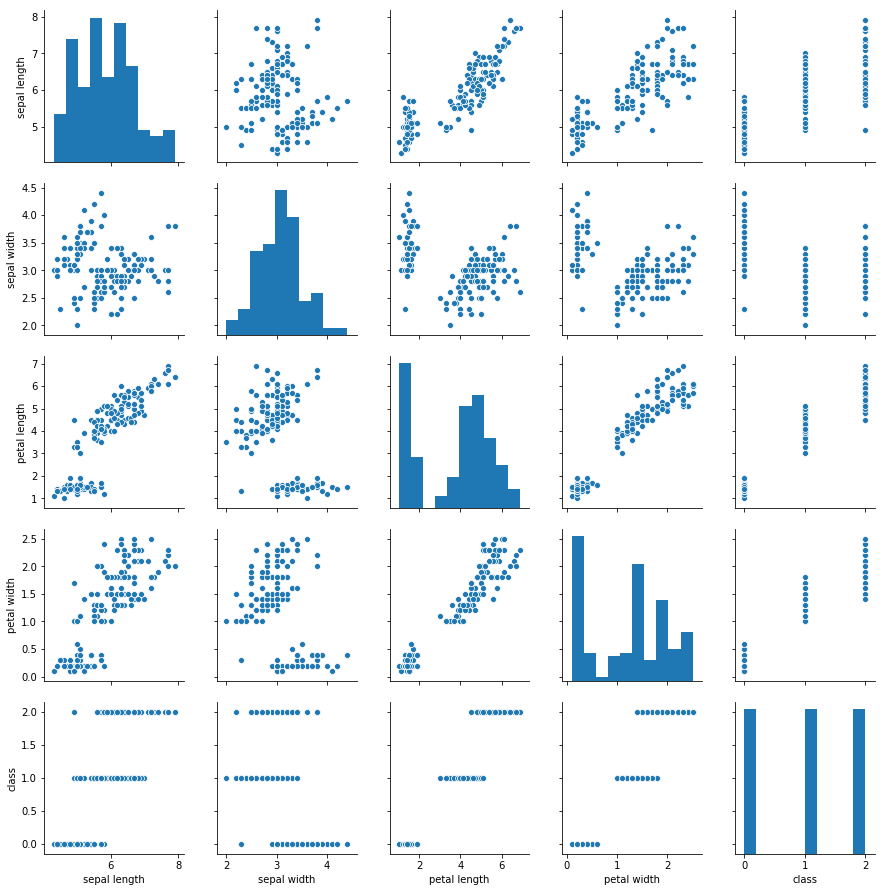

In [459]:
# Pairplot using sns
sns.pairplot(iris_df)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [460]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [461]:
def KNNPerformanceAnalysis(X, y, n_neighbors, test_size = 0.2, seed = 7):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    NNH = KNeighborsClassifier(n_neighbors)
    NNH.fit(X_train, y_train)
    # Test accuracy numbers
    testPreds = NNH.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    return testAccuracy

In [462]:
K = [3,5,9]
for i in K:
    accuracy = KNNPerformanceAnalysis(X, y, i)
    print ("K-Value={} Accuracy-Score={}".format(i, accuracy))   

K-Value=3 Accuracy-Score=0.8666666666666667
K-Value=5 Accuracy-Score=0.9
K-Value=9 Accuracy-Score=0.9


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [463]:
opt_accuracy = 0
opt_kvalue = 0
opt_mse = 1
testResults = {}
for k in range(1,20):
    if (k%2):
        model_accuracy = KNNPerformanceAnalysis(X, y, k)
        model_mse = 1 - model_accuracy
        print ("k = {} Accuracy= {} MSE= {}".format(k, model_accuracy, model_mse))
        testResults[k] = model_mse
        if model_mse < opt_mse:
            opt_mse = model_mse
            opt_kvalue = k
            opt_accuracy = model_accuracy
            
print ("\nOptimal-K-Value={} Test-Accuracy={} MSE={} \n".format(opt_kvalue, opt_accuracy, opt_mse))           

k = 1 Accuracy= 0.9 MSE= 0.09999999999999998
k = 3 Accuracy= 0.8666666666666667 MSE= 0.1333333333333333
k = 5 Accuracy= 0.9 MSE= 0.09999999999999998
k = 7 Accuracy= 0.9333333333333333 MSE= 0.06666666666666665
k = 9 Accuracy= 0.9 MSE= 0.09999999999999998
k = 11 Accuracy= 0.9 MSE= 0.09999999999999998
k = 13 Accuracy= 0.8666666666666667 MSE= 0.1333333333333333
k = 15 Accuracy= 0.8666666666666667 MSE= 0.1333333333333333
k = 17 Accuracy= 0.8666666666666667 MSE= 0.1333333333333333
k = 19 Accuracy= 0.8666666666666667 MSE= 0.1333333333333333

Optimal-K-Value=7 Test-Accuracy=0.9333333333333333 MSE=0.06666666666666665 



## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

In [464]:
k_values = list (testResults.keys())
mse_values =  list(testResults.values())

Text(0.5, 1.0, 'K vs MSE')

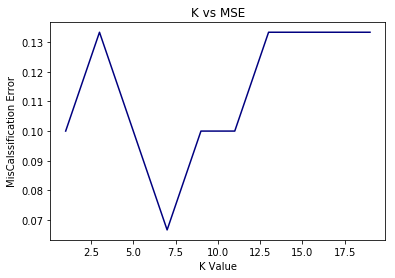

In [465]:
plt.plot(k_values, mse_values, color='navy')
plt.xlabel('K Value')
plt.ylabel('MisCalssification Error')
plt.title('K vs MSE')


# Naive Bayes with Iris Data

In [466]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [480]:
# X captures the independent variable 
X.head().T

,0,1,2,3,4
sepal length,-0.900681,-1.143017,-1.385353,-1.506521,-1.021849
sepal width,1.032057,-0.124958,0.337848,0.106445,1.263460
petal length,-1.341272,-1.341272,-1.398138,-1.284407,-1.341272
petal width,-1.312977,-1.312977,-1.312977,-1.312977,-1.312977


In [481]:
# Capture the class values from the 'class' column into a pandas series akin to array 
y = iris_df[["class"]]

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

In [482]:
y.count()

class    150
dtype: int64

Text(0.5, 0, 'Class')

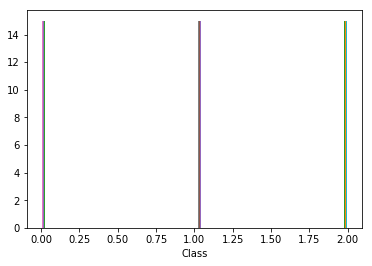

In [483]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.hist(y, normed=True, bins=30)
plt.xlabel('Class')

### Question 12 
Find Correlation among all variables and give your insights 

In [484]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [485]:
iris_df.corr()

,sepal length,sepal width,petal length,petal width,class
sepal length,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal length,0.871754,-0.420516,1.000000,0.962757,0.949043
petal width,0.817954,-0.356544,0.962757,1.000000,0.956464
class,0.782561,-0.419446,0.949043,0.956464,1.000000


In [486]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
sepal length    150 non-null float64
sepal width     150 non-null float64
petal length    150 non-null float64
petal width     150 non-null float64
dtypes: float64(4)
memory usage: 4.8 KB


#### Remove features, where correlation > 0.9 

In [487]:
X = X.drop(labels= ["petal length", "petal width" ] , axis = 1)

In [488]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
sepal length    150 non-null float64
sepal width     150 non-null float64
dtypes: float64(2)
memory usage: 2.4 KB


### Split data in Training and test set in 80:20.

In [489]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=7)

### Question 13 
Do Feature Scaling 

In [490]:
# zscore normalization already done on independent features in X (as part of KNN)

### Question 14 
Train and Fit NaiveBayes Model

In [491]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB(priors=None, var_smoothing=1e-09)

In [492]:
# make predictions on test
testPreds = model.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [493]:
# show Confusion Matrix
metrics.confusion_matrix(y_test, testPreds)

array([[6, 1, 0],
       [0, 3, 5],
       [0, 2, 3]], dtype=int64)

In [494]:
#Show accuracy,  precision and Recall metrics
testAccuracy = accuracy_score(y_test, testPreds)
print ("TestAccuracy=", testAccuracy)

TestAccuracy= 0.6


In [495]:
cr = metrics.classification_report(y_test, testPreds)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.50      0.38      0.43         8
           2       0.38      0.60      0.46         5

   micro avg       0.60      0.60      0.60        20
   macro avg       0.62      0.61      0.60        20
weighted avg       0.64      0.60      0.61        20



# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [ ]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [ ]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [ ]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [ ]:
# use from sklearn.svm import SVC

In [ ]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [ ]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [ ]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [ ]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [ ]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [ ]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [ ]:
gs.best_score_ 

0.77777777777777779